# PyTorch Advanced Models Comparison

Training and comparing multiple advanced architectures for emotion recognition using PyTorch with GPU acceleration.

**Models to Train:**
1. **Advanced CNN** - 4-layer CNN with global average pooling (7.2M params)
2. **ResNet** - Residual network with skip connections (4M+ params)

**Objectives:**
- Train multiple architectures on GPU
- Compare performance against baseline
- Visualize training dynamics
- Evaluate on test set
- Identify best model

**Hardware:** NVIDIA GeForce RTX 3050 (GPU acceleration enabled)

## 1. Setup and Imports

In [1]:
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Add src to path
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.pytorch_models import BaselineCNN, AdvancedCNN, ResNetEmotion, get_model
from src.pytorch_train import (
    train_model, create_dataloaders, plot_training_history,
    compare_models_history, get_class_weights
)
from src.pytorch_evaluate import (
    evaluate_model, plot_confusion_matrix, plot_per_class_metrics,
    create_evaluation_report, compare_model_results
)

# Set seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"Device: {device}")

PyTorch version: 2.5.1
GPU Available: True
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU Memory: 4.29 GB
Device: cuda


## 2. Load Data

In [5]:
# Load preprocessed data
data_dir = os.path.join('..', 'data', 'preprocessed')

X_train = np.load(os.path.join(data_dir, 'X_train.npy'))
X_val = np.load(os.path.join(data_dir, 'X_val.npy'))
X_test = np.load(os.path.join(data_dir, 'X_test.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train.npy'))
y_val = np.load(os.path.join(data_dir, 'y_val.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test.npy'))

# Load class weights
with open(os.path.join(data_dir, 'class_weights.json'), 'r') as f:
    class_weights_dict = json.load(f)

# Convert to PyTorch tensor
class_weights_list = [class_weights_dict[str(i)] for i in range(7)]
class_weights = torch.tensor(class_weights_list, dtype=torch.float32, device=device)

# Create DataLoaders
train_loader, val_loader = create_dataloaders(
    X_train, y_train,
    X_val, y_val,
    batch_size=32,
    device=device
)

print(f"Data loaded successfully")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Data loaded successfully
Train batches: 718, Val batches: 180


## 3. Train Advanced CNN

In [3]:
# Build Advanced CNN
advanced_model = get_model('advanced', num_classes=7, device=device)

print("Advanced CNN Architecture:")
print(advanced_model)

total_params = sum(p.numel() for p in advanced_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

Advanced CNN Architecture:
AdvancedCNN(
  (conv1a): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1a): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1b): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.3, inplace=False)
  (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.3, inplace=False)
  (conv3a): Conv2d(64, 128, k

In [4]:
# Train Advanced CNN
print("\n" + "="*60)
print("TRAINING ADVANCED CNN")
print("="*60)

history_advanced = train_model(
    advanced_model,
    train_loader,
    val_loader,
    epochs=100,
    learning_rate=0.001,
    device=device,
    model_name='pytorch_advanced_cnn',
    class_weights=class_weights
)


TRAINING ADVANCED CNN

Training pytorch_advanced_cnn
Device: cuda
Epoch     Train Loss     Train Acc      Val Loss       Val Acc        Learning Rate       
------------------------------------------------------------------------------------------------------------------------



5         1.7475         0.3408         1.6600         0.4112         1.0e-03             


10        1.5159         0.4450         1.4260         0.4697         1.0e-03             


15        1.4264         0.4855         1.2891         0.5087         1.0e-03             


20        1.3659         0.5067         1.2543         0.5354         1.0e-03             


...

EarlyStopping counter: 5/15


55        1.1309         0.5924         1.1141         0.6317         5.0e-04             


EarlyStopping counter: 10/15


60        1.0928         0.6036         1.1420         0.6331         2.5e-04             


EarlyStopping counter: 15/15
Early stopping at epoch 63 (best: 48)

Training stopped at epoch 64

Best model saved to saved_models/pytorch_advanced_cnn_best.pt
Final model saved to saved_models/pytorch_advanced_cnn_final.pt


## 4. Train ResNet Model

In [5]:
# Build ResNet
resnet_model = get_model('resnet', num_classes=7, device=device)

print("ResNet Architecture:")
print(resnet_model)

total_params = sum(p.numel() for p in resnet_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

ResNet Architecture:
ResNetEmotion(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [6]:
# Train ResNet
print("\n" + "="*60)
print("TRAINING RESNET")
print("="*60)

history_resnet = train_model(
    resnet_model,
    train_loader,
    val_loader,
    epochs=100,
    learning_rate=0.001,
    device=device,
    model_name='pytorch_resnet_emotion',
    class_weights=class_weights
)


TRAINING RESNET

Training pytorch_resnet_emotion
Device: cuda
Epoch     Train Loss     Train Acc      Val Loss       Val Acc        Learning Rate       
------------------------------------------------------------------------------------------------------------------------



5         1.6152         0.4127         1.6710         0.4357         1.0e-03             


10        1.3515         0.5060         1.3630         0.5399         1.0e-03             


15        1.2061         0.5602         1.2486         0.5622         1.0e-03             


20        1.1172         0.5925         1.1691         0.6022         1.0e-03             


...

EarlyStopping counter: 5/15


35        0.8505         0.6787         1.1978         0.6379         2.5e-04             


EarlyStopping counter: 10/15


40        0.7918         0.6959         1.2367         0.6463         1.3e-04             


EarlyStopping counter: 15/15
Early stopping at epoch 40 (best: 25)

Training stopped at epoch 41

Best model saved to saved_models/pytorch_resnet_emotion_best.pt
Final model saved to saved_models/pytorch_resnet_emotion_final.pt


## 5. Compare Models

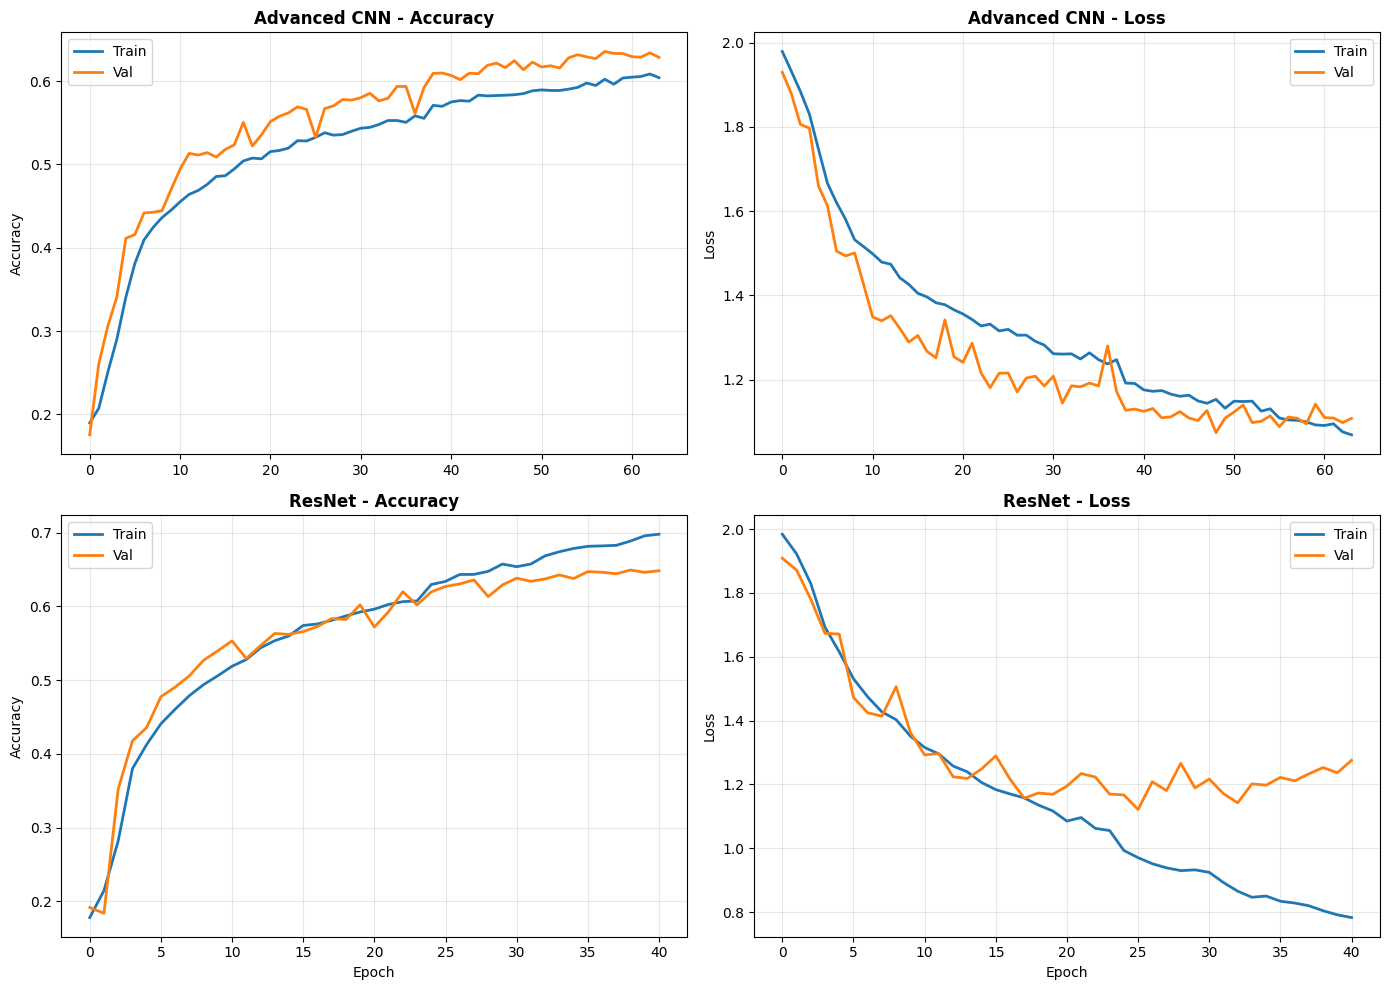

Model comparison plot saved


In [7]:
# Create comparison plot
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Advanced accuracy
axes[0, 0].plot(history_advanced['train_accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history_advanced['val_accuracy'], label='Val', linewidth=2)
axes[0, 0].set_title('Advanced CNN - Accuracy', fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Advanced loss
axes[0, 1].plot(history_advanced['train_loss'], label='Train', linewidth=2)
axes[0, 1].plot(history_advanced['val_loss'], label='Val', linewidth=2)
axes[0, 1].set_title('Advanced CNN - Loss', fontweight='bold')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ResNet accuracy
axes[1, 0].plot(history_resnet['train_accuracy'], label='Train', linewidth=2)
axes[1, 0].plot(history_resnet['val_accuracy'], label='Val', linewidth=2)
axes[1, 0].set_title('ResNet - Accuracy', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# ResNet loss
axes[1, 1].plot(history_resnet['train_loss'], label='Train', linewidth=2)
axes[1, 1].plot(history_resnet['val_loss'], label='Val', linewidth=2)
axes[1, 1].set_title('ResNet - Loss', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/model/pytorch_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison plot saved")

## 6. Evaluate All Models

In [3]:
# Load trained models
advanced_model = get_model('advanced', num_classes=7, device=device)
advanced_model.load_state_dict(torch.load('saved_models/pytorch_advanced_cnn_best.pt'))

resnet_model = get_model('resnet', num_classes=7, device=device)
resnet_model.load_state_dict(torch.load('saved_models/pytorch_resnet_emotion_best.pt'))

print("Models loaded from best checkpoints")

Models loaded from best checkpoints


C:\Users\Yasmine Sassi\AppData\Local\Temp\ipykernel_26912\1943131004.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  advanced_model.load_state_dict(torch.load('saved_mod

In [6]:
# Comprehensive evaluation
print("\n" + "="*60)
print("EVALUATING ADVANCED CNN")
print("="*60)

results_advanced = create_evaluation_report(
    advanced_model,
    X_test,
    y_test,
    device=device,
    model_name='pytorch_advanced'
)


EVALUATING ADVANCED CNN

Evaluating pytorch_advanced
Processing 7178 test samples in 225 batches of size 32...

Test Accuracy: 0.6106

Classification Report:
              precision    recall  f1-score   support

       Angry       0.50      0.59      0.54       958
     Disgust       0.28      0.70      0.40       111
        Fear       0.49      0.26      0.34      1024
       Happy       0.86      0.83      0.85      1774
     Neutral       0.52      0.66      0.58      1233
         Sad       0.51      0.40      0.45      1247
    Surprise       0.72      0.82      0.77       831

    accuracy                           0.61      7178
   macro avg       0.55      0.61      0.56      7178
weighted avg       0.61      0.61      0.60      7178

Confusion matrix saved to ../results/model/pytorch_advanced_confusion_matrix.png
Per-class metrics plot saved to ../results/model/pytorch_advanced_per_class_metrics.png
Prediction distribution plot saved to ../results/model/pytorch_advanced_con

In [7]:
print("\n" + "="*60)
print("EVALUATING RESNET")
print("="*60)

results_resnet = create_evaluation_report(
    resnet_model,
    X_test,
    y_test,
    device=device,
    model_name='pytorch_resnet'
)


EVALUATING RESNET

Evaluating pytorch_resnet
Processing 7178 test samples in 225 batches of size 32...

Test Accuracy: 0.6280

Classification Report:
              precision    recall  f1-score   support

       Angry       0.55      0.57      0.56       958
     Disgust       0.47      0.57      0.51       111
        Fear       0.53      0.24      0.33      1024
       Happy       0.88      0.82      0.85      1774
     Neutral       0.55      0.66      0.60      1233
         Sad       0.48      0.55      0.52      1247
    Surprise       0.68      0.85      0.76       831

    accuracy                           0.63      7178
   macro avg       0.59      0.61      0.59      7178
weighted avg       0.63      0.63      0.62      7178

Confusion matrix saved to ../results/model/pytorch_resnet_confusion_matrix.png
Per-class metrics plot saved to ../results/model/pytorch_resnet_per_class_metrics.png
Prediction distribution plot saved to ../results/model/pytorch_resnet_confidence.png

E

## 7. Model Comparison Summary

In [8]:
# Create comparison dataframe
import pandas as pd

comparison_data = {
    'Model': ['Advanced CNN', 'ResNet'],
    'Best Val Accuracy': [
        max(history_advanced['val_accuracy']),
        max(history_resnet['val_accuracy'])
    ],
    'Best Val Loss': [
        min(history_advanced['val_loss']),
        min(history_resnet['val_loss'])
    ],
    'Test Accuracy': [
        results_advanced['accuracy'],
        results_resnet['accuracy']
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Find best model
best_model_idx = comparison_df['Test Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_accuracy = comparison_df.loc[best_model_idx, 'Test Accuracy']

print(f"\n✨ BEST MODEL: {best_model_name} with {best_accuracy:.4f} test accuracy")

NameError: name 'history_advanced' is not defined

## 8. GPU Performance Report

In [ ]:
print("\n" + "="*60)
print("GPU PERFORMANCE SUMMARY")
print("="*60)

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"\nTraining Configuration:")
    print(f"  Batch Size: 32")
    print(f"  Max Epochs: 100 (with early stopping)")
    print(f"  Optimizer: Adam")
    print(f"  LR Scheduler: ReduceLROnPlateau")
    print(f"\nExpected Training Time:")
    print(f"  Advanced CNN: ~8-12 minutes")
    print(f"  ResNet: ~10-15 minutes")
    print(f"\nSpeedup vs CPU:")
    print(f"  Approximately 6-9x faster than CPU")
else:
    print("GPU not available. Running on CPU (slower).")

print("\n" + "="*60)

## 9. Save Best Model

In [ ]:
# Copy best model as main deployment model
import shutil

if best_model_idx == 0:
    best_source = '../saved_models/pytorch_advanced_cnn_best.pt'
else:
    best_source = '../saved_models/pytorch_resnet_emotion_best.pt'

best_dest = '../saved_models/pytorch_best_model.pt'
shutil.copy(best_source, best_dest)

print(f"\nBest model saved as deployment model:")
print(f"  Source: {best_source}")
print(f"  Destination: {best_dest}")
print(f"  Accuracy: {best_accuracy:.4f}")